# Multivariate Prediction

Running MVPA style analyses using multivariate regression is even easier and faster
than univariate methods. All you need to do is specify the algorithm and
cross-validation parameters. Currently, we have several different linear algorithms
implemented from [scikit-learn](http://scikit-learn.org/stable/).

## Load Data

First, let's load the pain data for this example.  We need to specify the
training levels.  We will grab the pain intensity variable from the data.X
field.

In [1]:
from nltools.datasets import fetch_pain

data = fetch_pain()
data.Y = data.X['PainLevel']

[get_dataset_dir] Dataset found in /Users/esh/nilearn_data/neurovault
[NiftiMasker.wrapped] Resampling images


/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images
[NiftiMasker.wrapped] Resampling images


## Prediction with Cross-Validation

We can now predict the output variable is a dictionary of the most
useful output from the prediction analyses. The predict function runs
the prediction multiple times. One of the iterations uses all of the
data to calculate the 'weight_map'. The other iterations are to estimate
the cross-validated predictive accuracy.

overall Root Mean Squared Error: 0.00
overall Correlation: 1.00
overall CV Root Mean Squared Error: 0.55
overall CV Correlation: 0.74


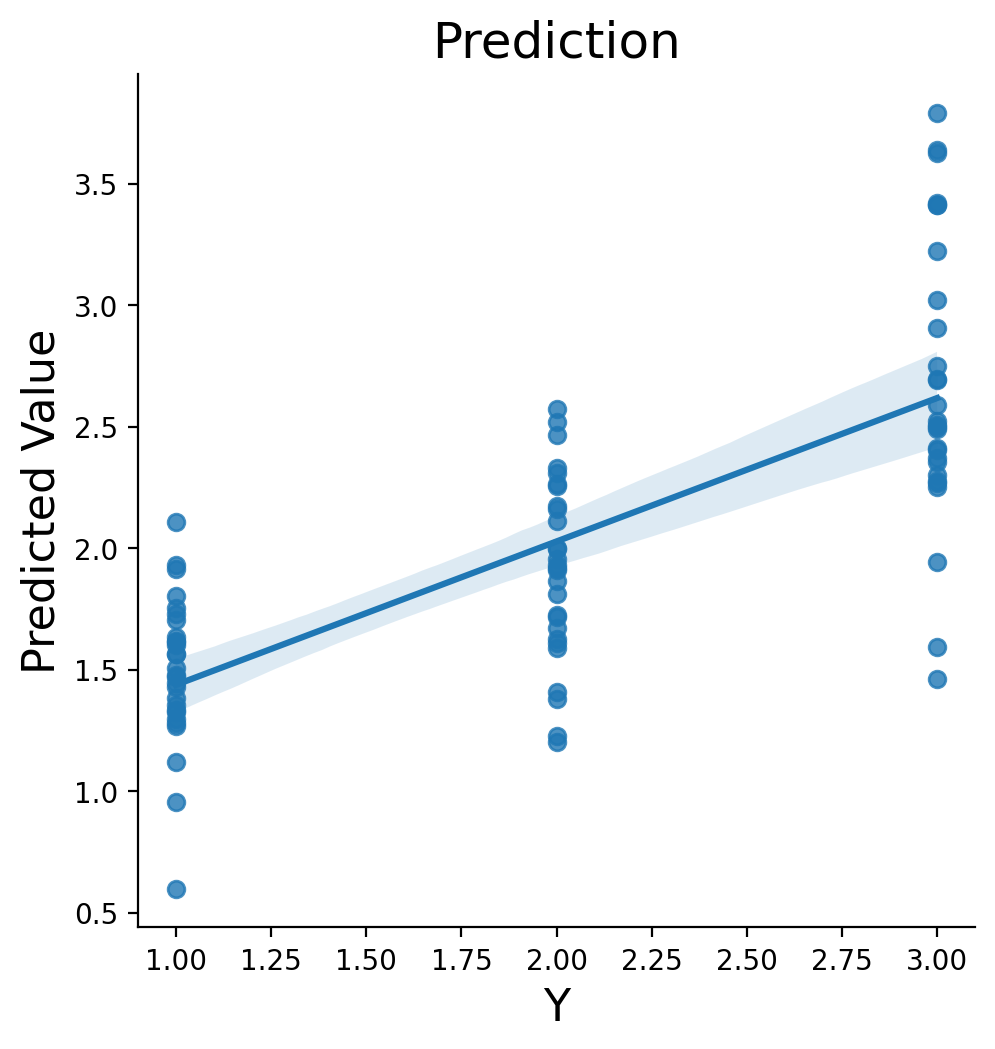

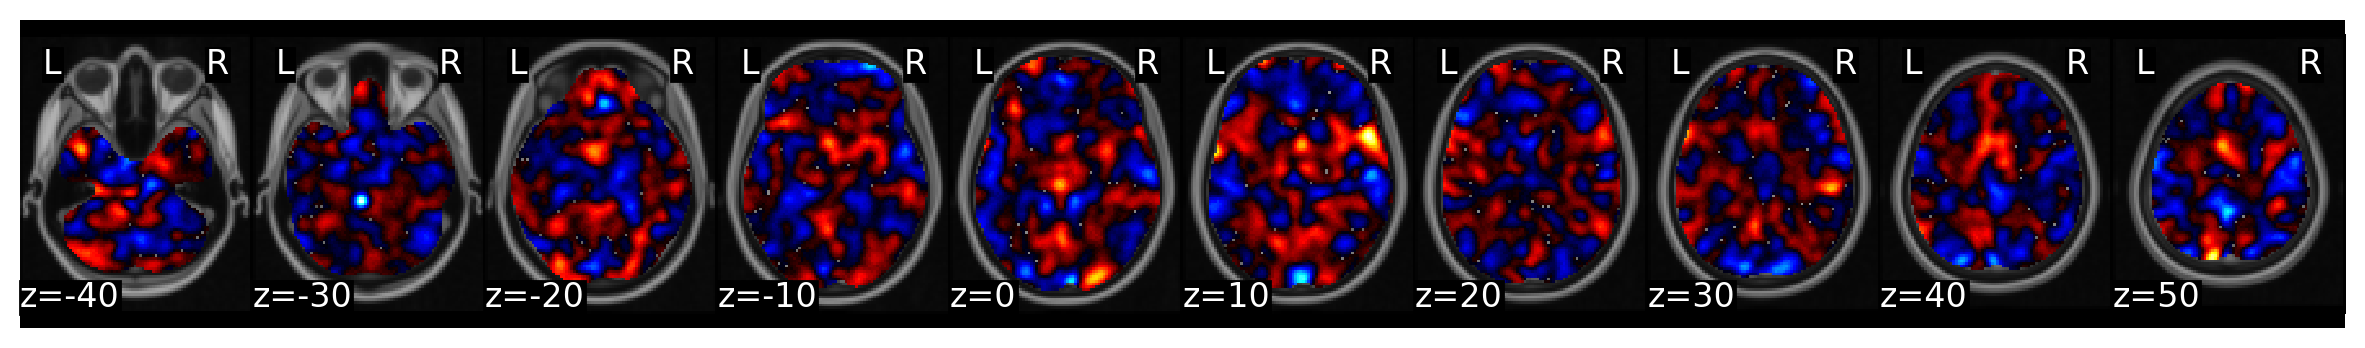

In [2]:
stats = data.predict(algorithm='ridge',
                    cv_dict={'type': 'kfolds','n_folds': 5,'stratified':data.Y})

Display the available data in the output dictionary

In [3]:
stats.keys()

dict_keys(['Y', 'yfit_all', 'intercept', 'weight_map', 'yfit_xval', 'intercept_xval', 'weight_map_xval', 'cv_idx', 'rmse_all', 'r_all', 'rmse_xval', 'r_xval'])

Plot the multivariate weight map

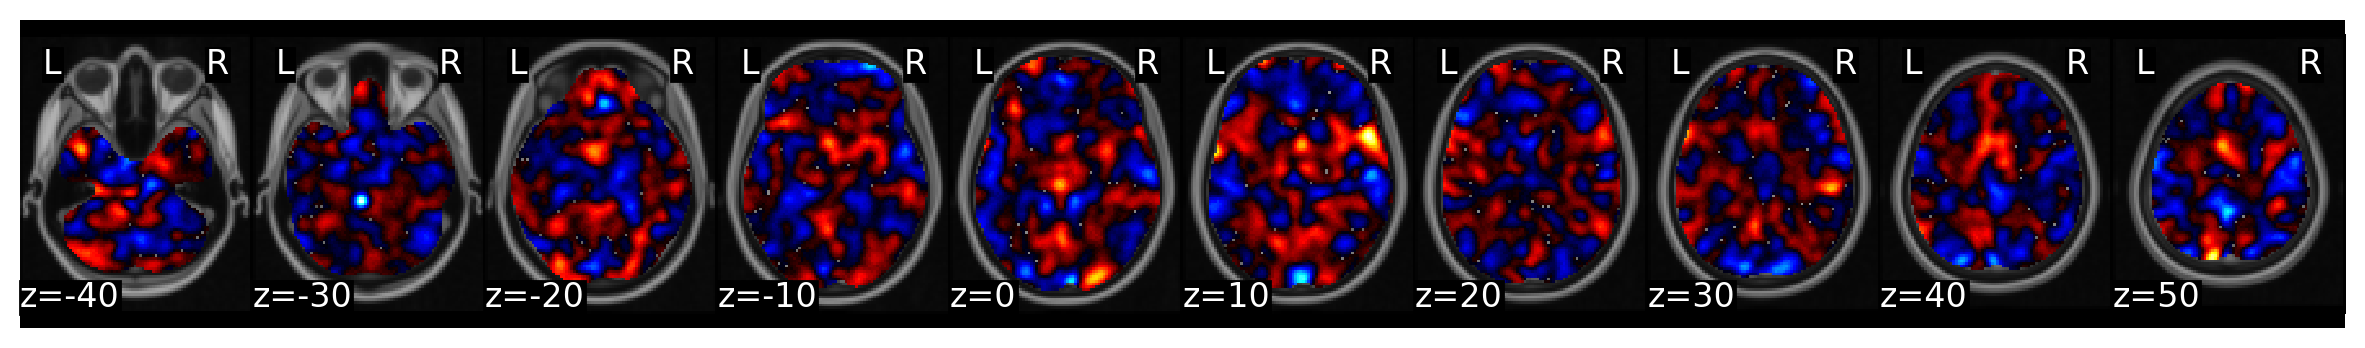

In [4]:
stats['weight_map'].plot()

Return the cross-validated predicted data

In [5]:
stats['yfit_xval']

array([0.95431274, 1.3562479 , 2.328466  , 2.267446  , 2.520301  ,
       1.2007886 , 2.250516  , 2.697494  , 1.8027344 , 1.9095461 ,
       2.1101995 , 1.6117266 , 2.5894332 , 1.9411752 , 1.3256483 ,
       2.2652035 , 1.7060925 , 1.505615  , 1.9315933 , 2.5072384 ,
       1.5909201 , 2.3030863 , 2.465016  , 2.5709224 , 3.4123268 ,
       1.3331456 , 0.59844524, 1.7168559 , 1.4798673 , 3.4218109 ,
       2.6937213 , 1.268614  , 1.9322253 , 1.6272414 , 2.498084  ,
       2.749585  , 2.4894252 , 1.9956359 , 1.8641344 , 1.2791111 ,
       1.4459941 , 1.4596149 , 1.6194685 , 1.4085059 , 1.2979321 ,
       1.428192  , 2.3105264 , 1.9573843 , 2.1611898 , 2.277953  ,
       3.6372364 , 1.6351157 , 3.7923212 , 1.3812547 , 2.4136467 ,
       2.1061711 , 1.6698565 , 1.7539898 , 1.3771837 , 1.5934036 ,
       3.2229812 , 3.4127483 , 2.9077787 , 3.6267297 , 1.7237973 ,
       1.6026269 , 1.9180032 , 1.4687246 , 2.4027472 , 1.2267743 ,
       2.5249195 , 2.3528714 , 2.000525  , 1.5650864 , 1.61306

## Algorithms

There are several types of linear algorithms implemented including:
Support Vector Machines (svr), Principal Components Analysis (pcr), and
penalized methods such as ridge and lasso.  These examples use 5-fold
cross-validation holding out the same subject in each fold.

overall Root Mean Squared Error: 0.10
overall Correlation: 0.99
overall CV Root Mean Squared Error: 0.88
overall CV Correlation: 0.57


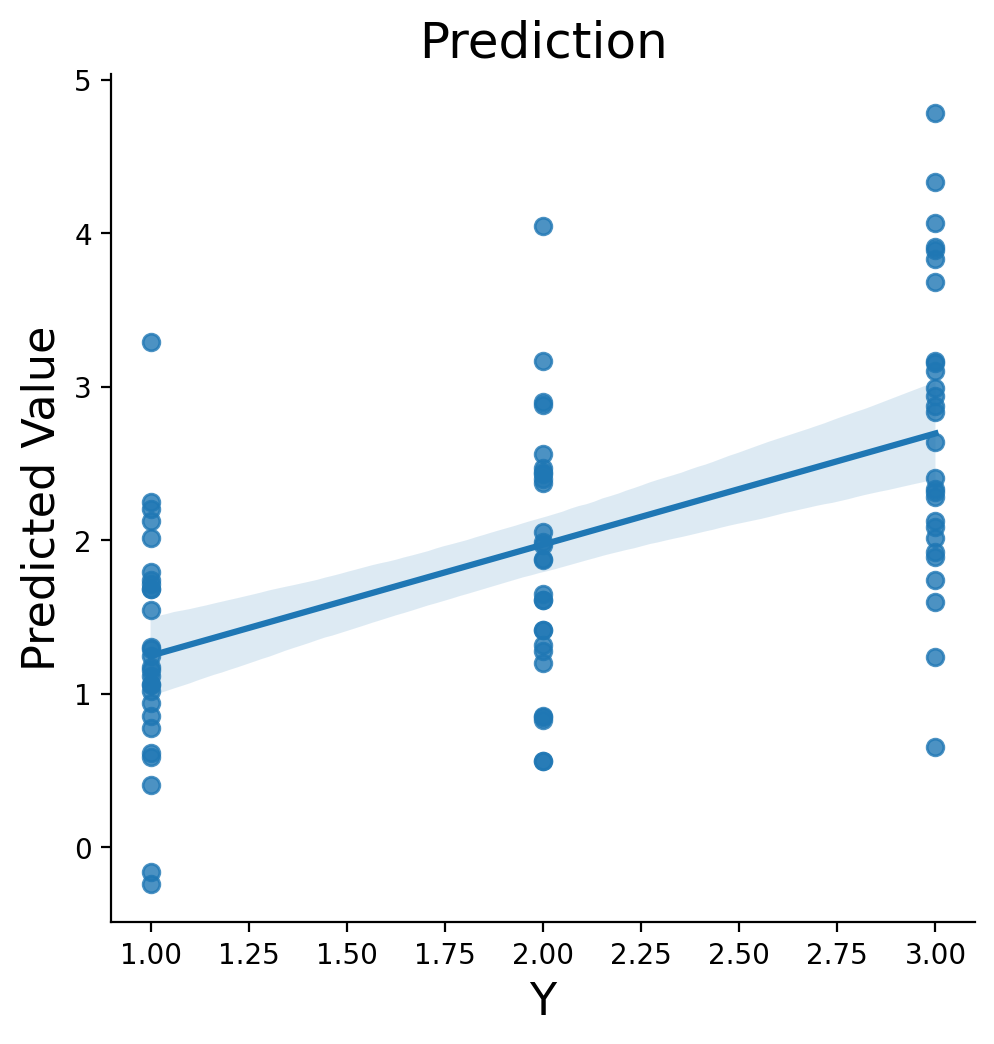

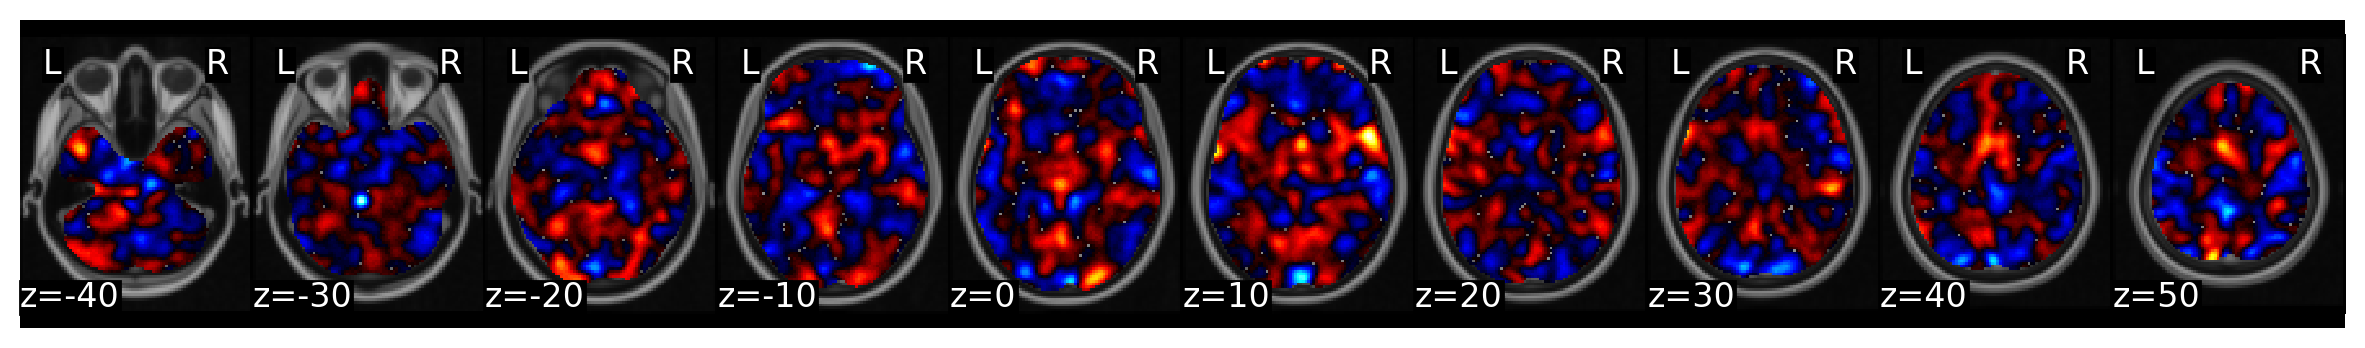

In [6]:
subject_id = data.X['SubjectID']
svr_stats = data.predict(algorithm='svr',
                        cv_dict={'type': 'kfolds','n_folds': 5,
                        'subject_id':subject_id}, **{'kernel':"linear"})

Lasso Regression

overall Root Mean Squared Error: 0.69
overall Correlation: 0.58
overall CV Root Mean Squared Error: 0.74
overall CV Correlation: 0.43


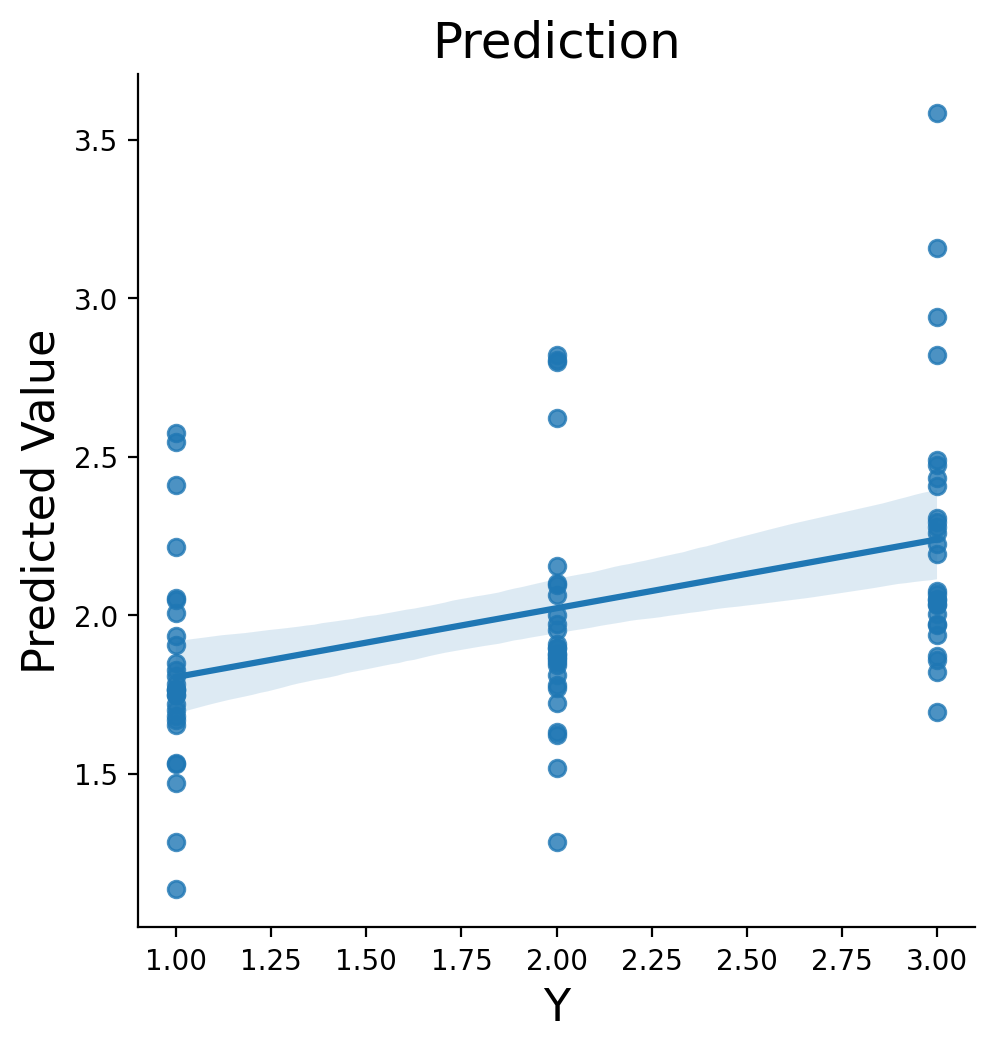

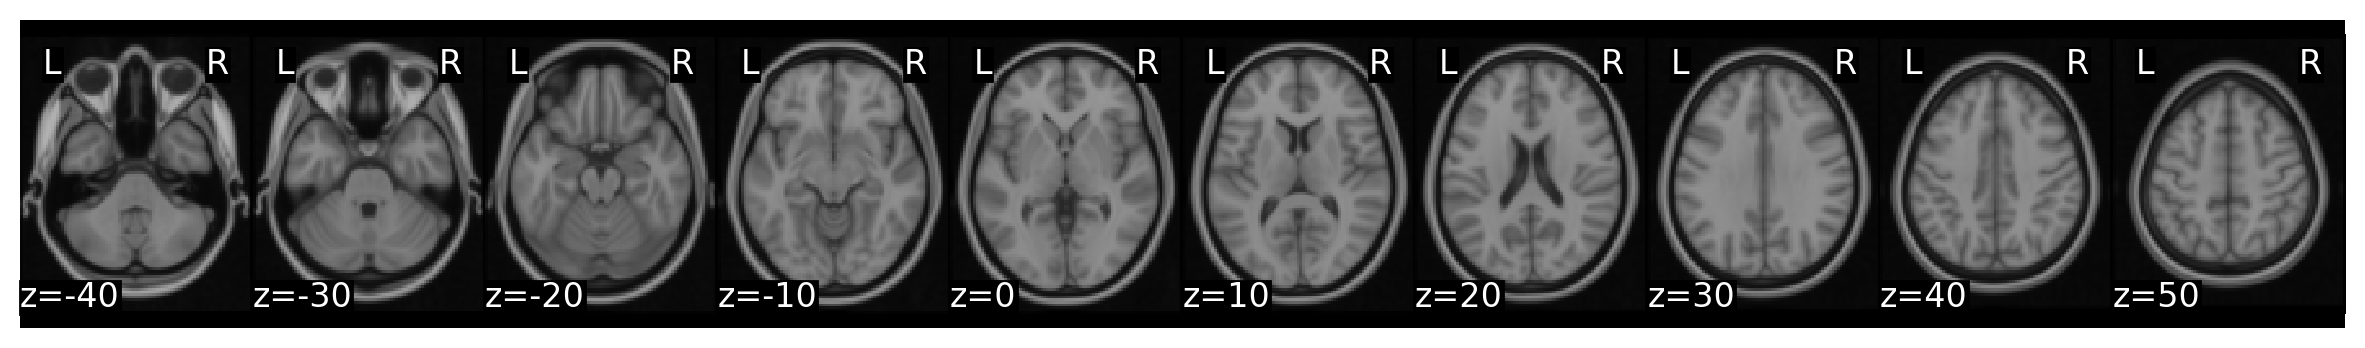

In [7]:
lasso_stats = data.predict(algorithm='lasso',
                        cv_dict={'type': 'kfolds','n_folds': 5,
                        'subject_id':subject_id}, **{'alpha':.1})

Principal Components Regression

overall Root Mean Squared Error: 0.00
overall Correlation: 1.00
overall CV Root Mean Squared Error: 0.91
overall CV Correlation: 0.58


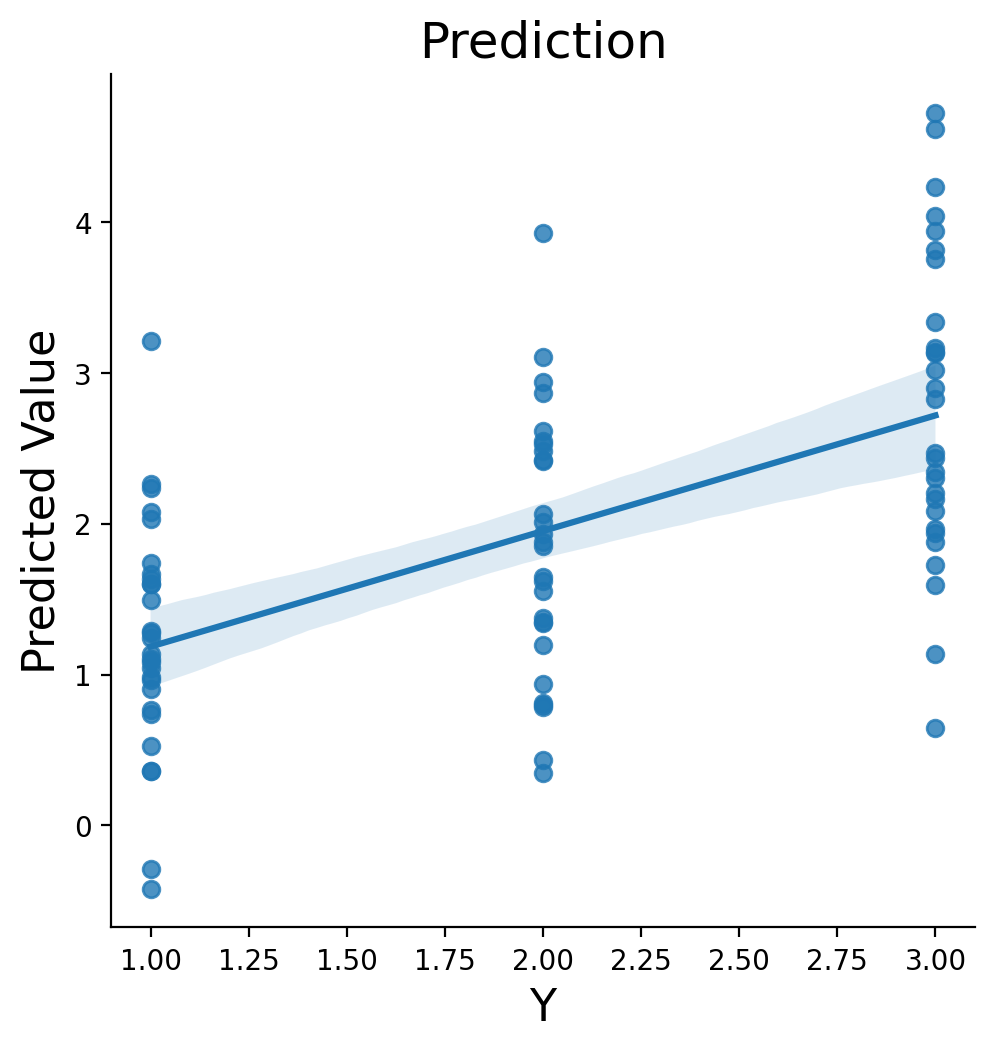

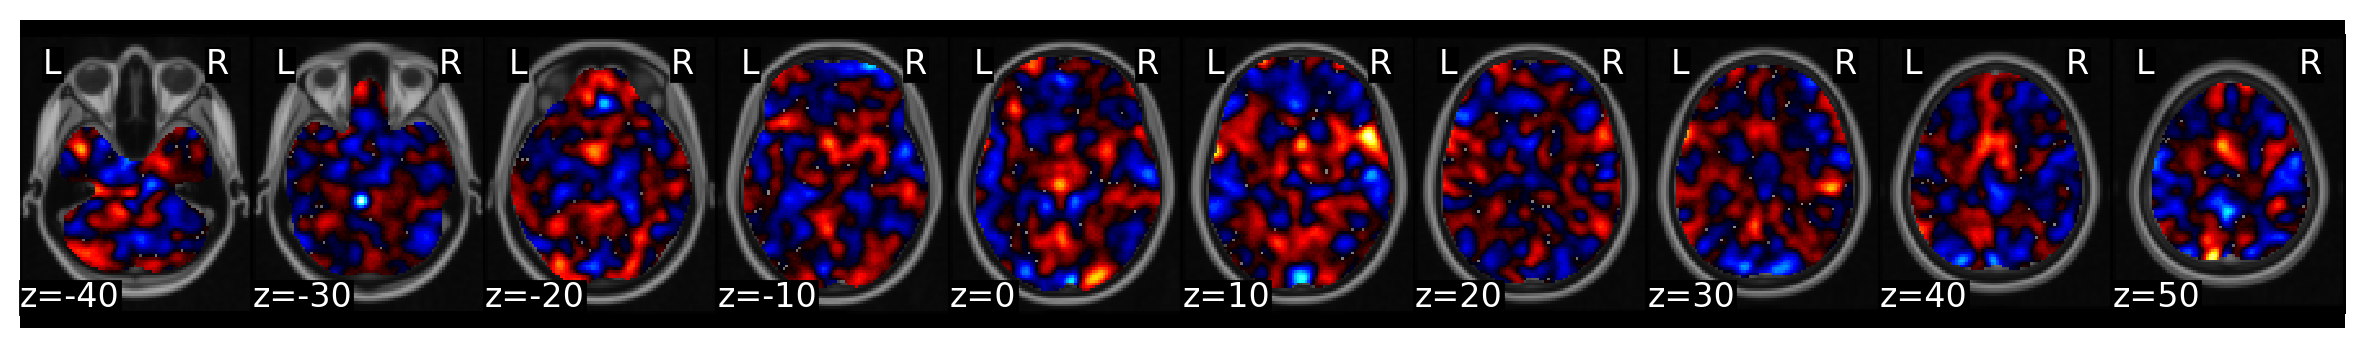

In [8]:
pcr_stats = data.predict(algorithm='pcr',
                        cv_dict={'type': 'kfolds','n_folds': 5,
                        'subject_id':subject_id})

Principal Components Regression with Lasso

overall Root Mean Squared Error: 0.48
overall Correlation: 0.84
overall CV Root Mean Squared Error: 0.73
overall CV Correlation: 0.54


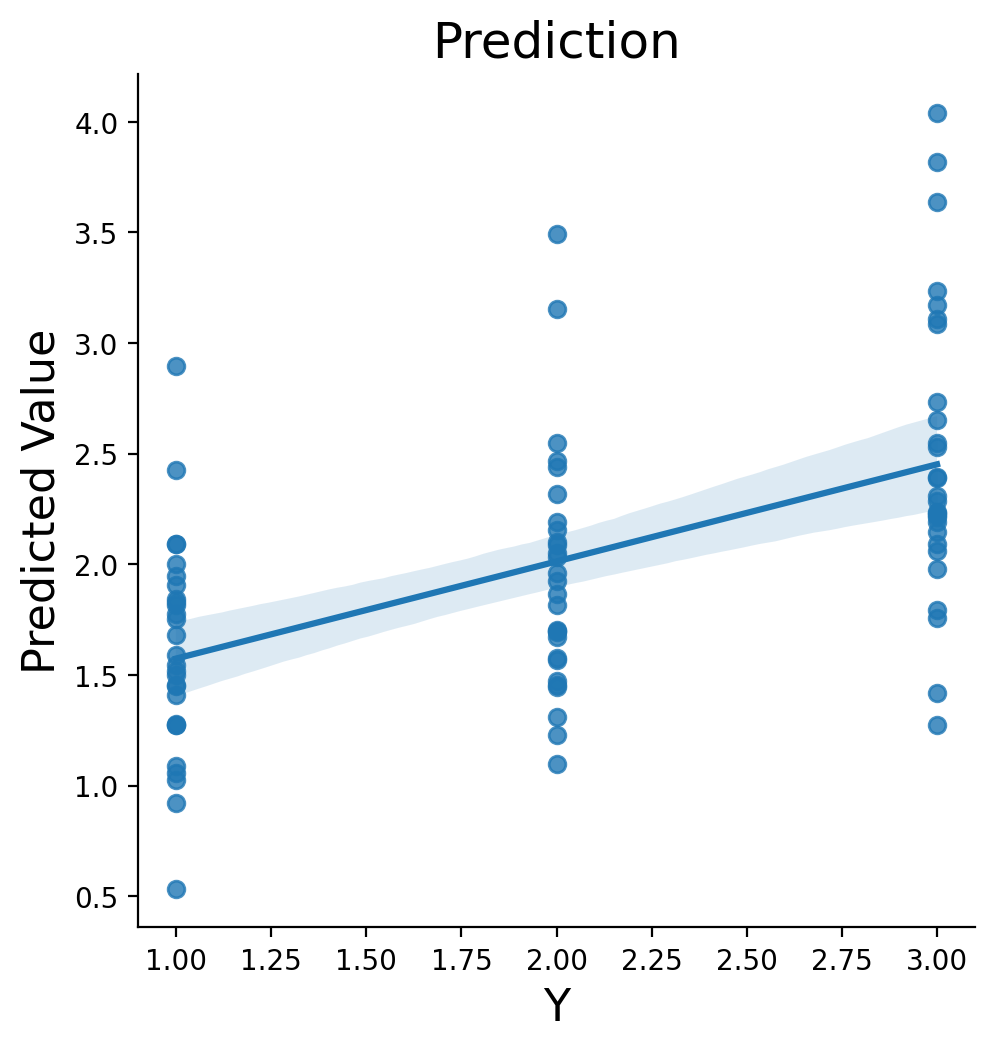

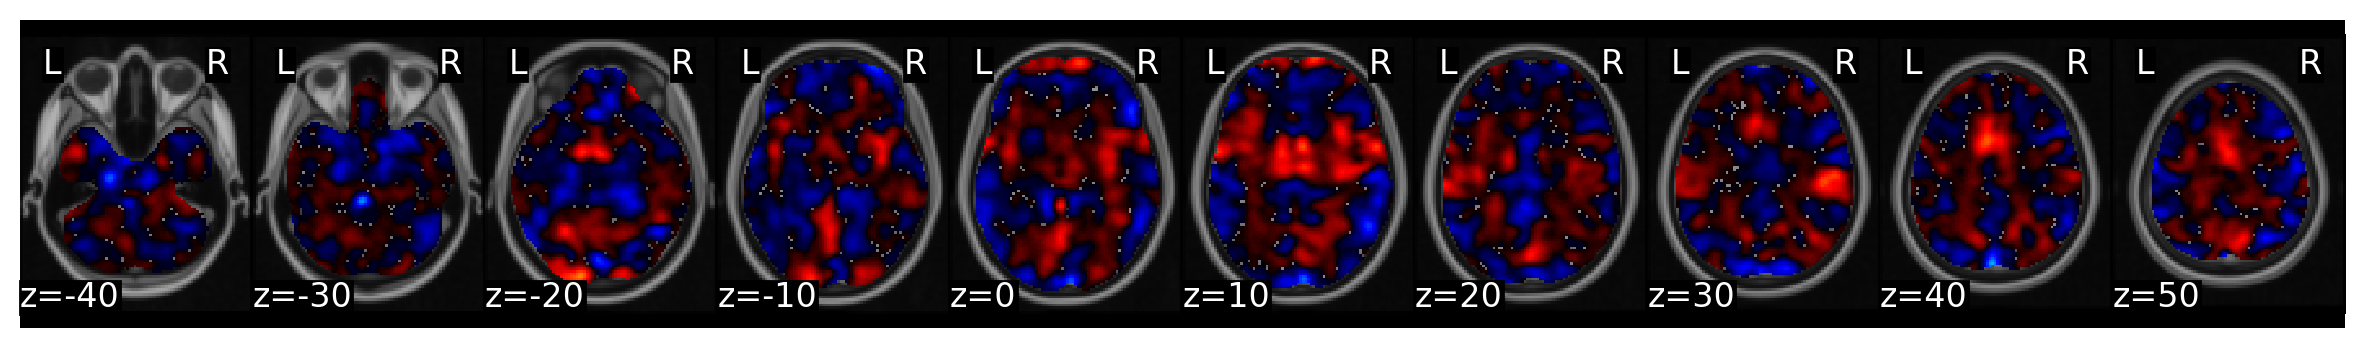

In [9]:
pcr_stats = data.predict(algorithm='lassopcr',
                        cv_dict={'type': 'kfolds','n_folds': 5,
                        'subject_id':subject_id})

## Cross-Validation Schemes

There are several different ways to perform cross-validation.  The standard
approach is to use k-folds, where the data is equally divided into k subsets
and each fold serves as both training and test.
Often we want to hold out the same subjects in each fold.
This can be done by passing in a vector of unique subject IDs that
correspond to the images in the data frame.

In [ ]:
subject_id = data.X['SubjectID']
ridge_stats = data.predict(algorithm='ridge',
                        cv_dict={'type': 'kfolds','n_folds': 5,'subject_id':subject_id},
                        plot=False, **{'alpha':.1})

Sometimes we want to ensure that the training labels are balanced across
folds.  This can be done using the stratified k-folds method.

In [ ]:
ridge_stats = data.predict(algorithm='ridge',
                        cv_dict={'type': 'kfolds','n_folds': 5, 'stratified':data.Y},
                        plot=False, **{'alpha':.1})

Leave One Subject Out Cross-Validaiton (LOSO) is when k=n subjects.
This can be performed by passing in a vector indicating subject id's of
each image and using the loso flag.

In [ ]:
ridge_stats = data.predict(algorithm='ridge',
                        cv_dict={'type': 'loso','subject_id': subject_id},
                        plot=False, **{'alpha':.1})

There are also methods to estimate the shrinkage parameter for the
penalized methods using nested crossvalidation with the
ridgeCV and lassoCV algorithms.

In [ ]:
import numpy as np

ridgecv_stats = data.predict(algorithm='ridgeCV',
                        cv_dict={'type': 'kfolds','n_folds': 5, 'stratified':data.Y},
                        plot=False, **{'alphas':np.linspace(.1, 10, 5)})